In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.wcs import WCS
from astropy.visualization import simple_norm

from spectral_cube import SpectralCube

from pvextractor import extract_pv_slice, Path

%matplotlib widget

In [2]:
cube = SpectralCube.read('./HI4PI/HI4PI_ALLSKY_GAL_CAR.fits')
cube = cube.with_spectral_unit(u.km / u.s)
# cube = cube.subcube(zlo=-450*u.km/u.s, zhi=450*u.km/u.s)


In [3]:
cube

SpectralCube with shape=(945, 2163, 4323) and unit=K:
 n_x:   4323  type_x: GLON-CAR  unit_x: deg    range:          nan deg:         nan deg
 n_y:   2163  type_y: GLAT-CAR  unit_y: deg    range:          nan deg:         nan deg
 n_s:    945  type_s: VRAD      unit_s: km / s  range:     -606.648 km / s:     609.427 km / s

In [4]:
subcube = cube[122:821, 1021:1142, :]
subcube

SpectralCube with shape=(699, 121, 4323) and unit=K:
 n_x:   4323  type_x: GLON-CAR  unit_x: deg    range:          nan deg:         nan deg
 n_y:    121  type_y: GLAT-CAR  unit_y: deg    range:          nan deg:         nan deg
 n_s:    699  type_s: VRAD      unit_s: km / s  range:     -449.486 km / s:     449.688 km / s

In [5]:
def displayimage(cube, path=None):
    img = cube.moment(order=0)  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3), layout="compressed", subplot_kw={"projection": cube.wcs.celestial}
    )
    norm = simple_norm(img.value, vmin=0, vmax=np.nanmax(img.value), stretch="linear")
    im = ax.imshow(img.value, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if path != None:
        path.show_on_axis(ax, spacing=1, color='white', lw=0.2)
    plt.colorbar(im)
    plt.show()

In [6]:
# path = Path([(20,20), (40,40), (60,20)])
path = Path([(0., 60.), (4322., 60.)], width=120)

/home/firestar/.miniconda/lib/python3.13/site-packages/pvextractor/geometry/path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))


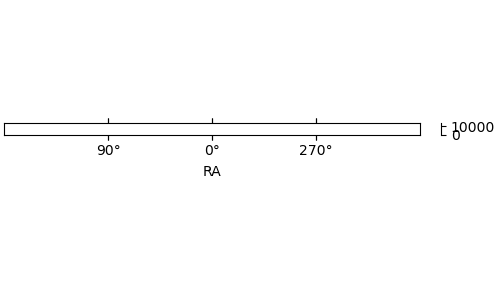

In [7]:
displayimage(subcube, path=path)

In [8]:
pvdiagram = extract_pv_slice(cube=subcube, path=path, spacing=5*u.arcmin)
pvdiagram

In [14]:
header = pvdiagram.header
header["CDELT1"] = -0.08333333330000001
header["CRPIX1"] = 2161.0
header["CRVAL1"] = 0.0
WCS(pvdiagram.header)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'OFFSET' 'VRAD' 
CRVAL : np.float64(0.0) np.float64(0.0) 
CRPIX : np.float64(2161.0) np.float64(349.9216300032) 
PC1_1 PC1_2  : np.float64(1.0) np.float64(0.0) 
PC2_1 PC2_2  : np.float64(0.0) np.float64(1.0) 
CDELT : np.float64(-0.0833333333) np.float64(1288.2149691242) 
NAXIS : 4321  699

In [15]:
pvdiagram.data.shape

(699, 4321)

In [16]:
pvdiagram.data

array([[-0.00349228, -0.00415282, -0.00599488, ...,  0.00124988,
        -0.00115309, -0.00292891],
       [-0.01851732, -0.01725747, -0.01415534, ..., -0.01319448,
        -0.0134669 , -0.01692969],
       [-0.01778052, -0.01796241, -0.01652473, ..., -0.01672206,
        -0.01604871, -0.01676795],
       ...,
       [ 0.01310066,  0.01374921,  0.011962  , ..., -0.00485501,
         0.00158024,  0.00932772],
       [ 0.00340936,  0.00413024,  0.00710218, ...,  0.00498044,
         0.00617213,  0.00477128],
       [ 0.00126877,  0.00427598,  0.00997103, ...,  0.00274026,
        -0.00010666,  0.00015079]], shape=(699, 4321))

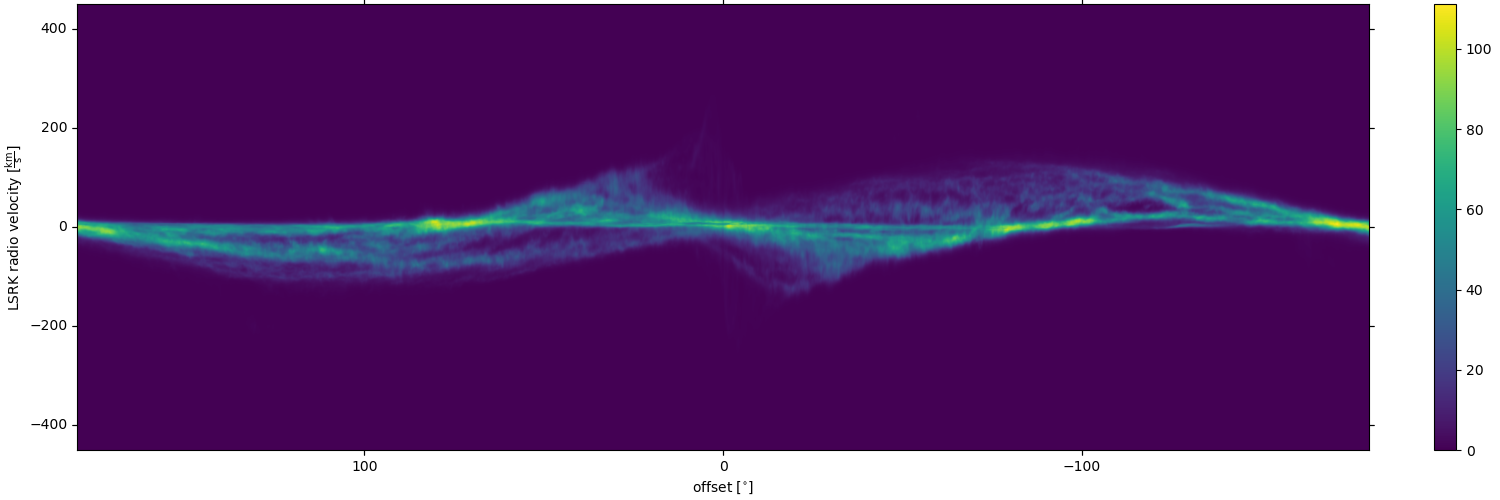

In [17]:
fig, ax = plt.subplots(
        figsize=(15, 5), layout="compressed", subplot_kw={"projection": WCS(pvdiagram.header)}
    )
im = ax.imshow(pvdiagram.data, aspect="auto")

#ax0 = ax.coords[0]
#ax0.set_format_unit(u.arcmin)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s)

plt.colorbar(im)
plt.show()

In [18]:
pvdiagram.writeto("HI4PI_Galatic_LV.fits", overwrite=True)